In [72]:
import sys
sys.path.append('../')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from src.visualizations import plot_experiment_results

In [76]:
results = pd.read_csv('../results/lsvt.csv')
df = results
# df

In [135]:
PALETTE = [
    '#3274A1',
    '#E1812C',
    '#A21010',
    '#BC2020',
    '#DC3030',
    '#F04040',
]

def get_oracle_mean_std(results: pd.DataFrame):
    oracle_mean = df[df['Approach'] == 'Oracle']['Accuracy'].mean()
    oracle_std = df[df['Approach'] == 'Oracle']['Accuracy'].std()
    return oracle_mean, oracle_std

def preprocess_results(df: pd.DataFrame):
    model_rename = {
        'LogisticRegression': 'LR',
        'RandomForestClassifier': 'RFC',
        'XGBClassifier': 'XGB',
        'SVC': 'SVC'
    }

    df = df.copy()

    df['base_estimator'] = df['base_estimator'].map(model_rename)

    df['k_best'] = df['k_best'].astype('Int64')

    df['estimator'] = df['base_estimator'] + '_' + df['k_best'].astype(str)

    df['Approach'] = np.where(
        df['Approach'] == 'self_training',
        'ST_' + df['estimator'],
        df['Approach']
    )

    return df

def make_scheme_labels(df, scheme_type):
    if scheme_type == 'MCAR':
        missing_med = df.groupby('Scheme')['Missing_Percent'].median().round(1)
        return df['Scheme'] + '\nMissing=' + df['Scheme'].map(missing_med).astype(str) + '%'
    
    if scheme_type == 'MAR1':
        base = 'MAR1\nw=' + df['w1'].astype(str) + ' b=' + df['b1'].astype(str)
        missing_med = df.groupby(['w1', 'b1'])['Missing_Percent'].median().round(1)
        med = df.set_index(['w1', 'b1']).index.map(missing_med)
        return base + '\nMissing=' + pd.Series(med, index=df.index).astype(str) + '%'
    
    if scheme_type == 'MAR2':
        base = 'MAR2\nw=' + df['w2'].astype(str) + ' b=' + df['b2'].astype(str)
        missing_med = df.groupby(['w2', 'b2'])['Missing_Percent'].median().round(1)
        med = df.set_index(['w2', 'b2']).index.map(missing_med)
        return base + '\nMissing=' + pd.Series(med, index=df.index).astype(str) + '%'
    
    if scheme_type == 'MNAR':
        base = (
            'MNAR\nwx=' + df['wx'].astype(str) +
            ' wy=' + df['wy'].astype(str) +
            ' by=' + df['by'].astype(str)
        )
        missing_med = df.groupby(['wx', 'wy', 'by'])['Missing_Percent'].median().round(1)
        med = df.set_index(['wx', 'wy', 'by']).index.map(missing_med)
        return base + '\nMissing=' + pd.Series(med, index=df.index).astype(str) + '%'

def boxplot_by_scheme(df: pd.DataFrame, metric: str, dataset_name: str, scheme_type: str):
    oracle_mean, _ = get_oracle_mean_std(df)

    df = preprocess_results(df)

    df = df[df['Scheme'].str.startswith(scheme_type)]

    # Only first 4 comb for MNAR
    if scheme_type == 'MNAR':
        first_4 = (df[['wx', 'wy', 'by']]
                   .drop_duplicates()
                   .head(4))
        df = df.merge(first_4, on=['wx', 'wy', 'by'])

    df['Scheme_label'] = make_scheme_labels(df, scheme_type)

    plt.figure(figsize=(11, 6))

    sns.boxplot(
        data=df,
        x='Scheme_label',
        y=metric,
        hue='Approach',
        hue_order=[
            'naive',
            'label_propagation',
            'ST_LR_1',
            'ST_RFC_1',
            'ST_XGB_1',
            'ST_SVC_1'
        ],
        palette=PALETTE,
        gap=0.1
    )

    plt.axhline(y=oracle_mean, linestyle='--', color='black', alpha=.6)

    plt.title(f'{dataset_name} - {metric}')
    plt.legend(loc='lower left')
    plt.tight_layout()

### MCAR

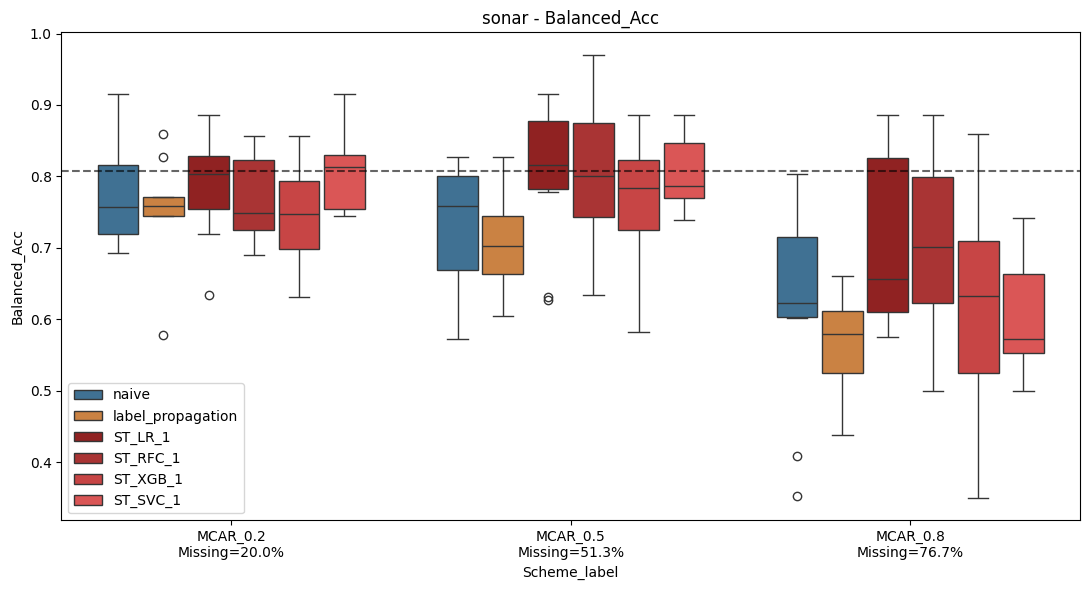

In [136]:
boxplot_by_scheme(results, 'Balanced_Acc', 'sonar', 'MCAR')

### MAR1

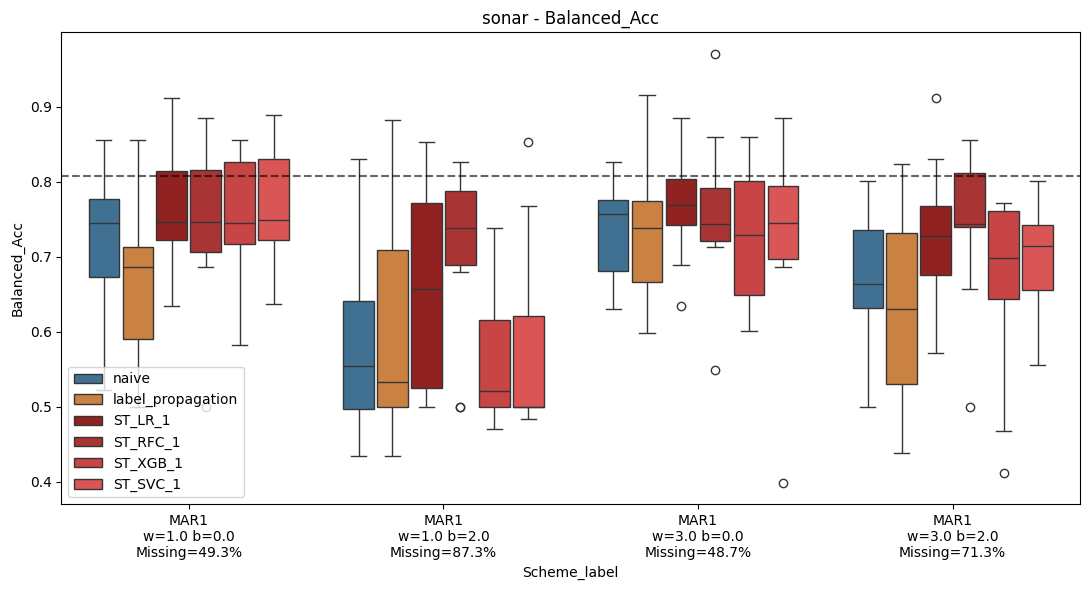

In [137]:
boxplot_by_scheme(results, 'Balanced_Acc', 'sonar', 'MAR1')

### MAR2

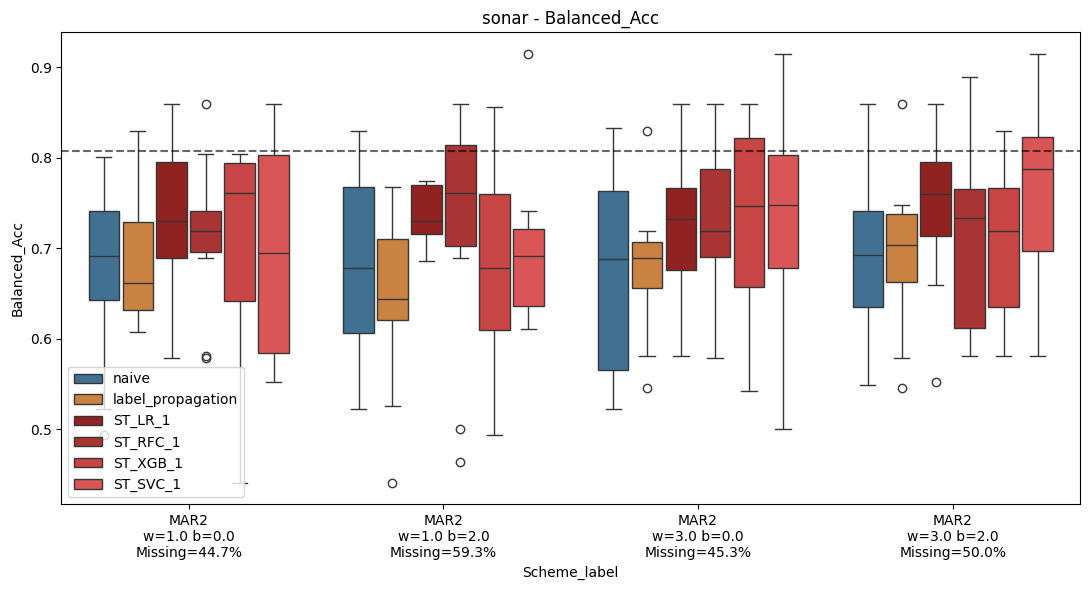

In [138]:
boxplot_by_scheme(results, 'Balanced_Acc', 'sonar', 'MAR2')

### MNAR

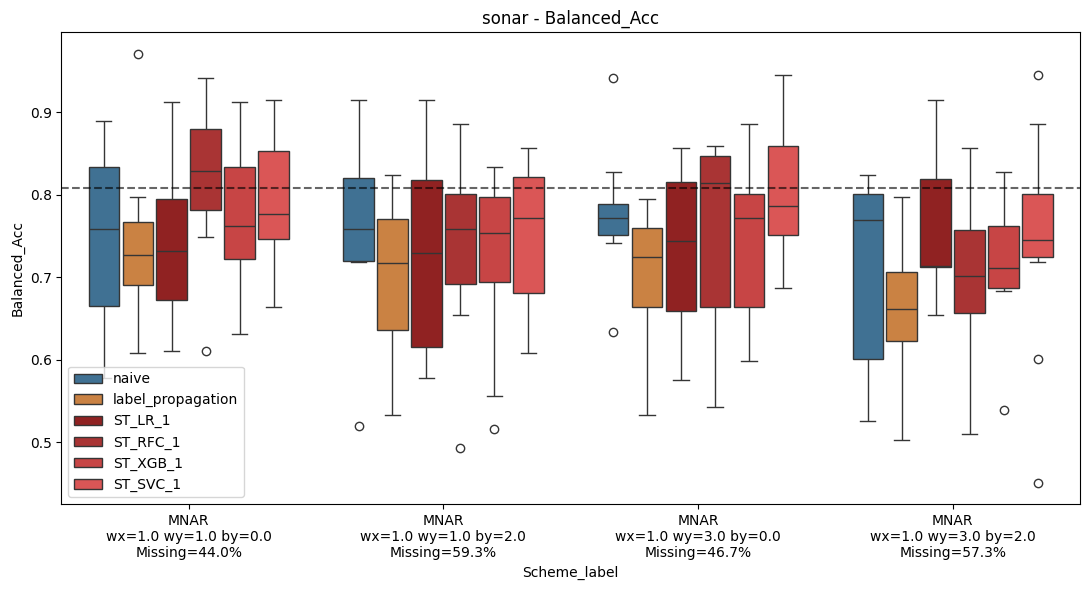

In [139]:

boxplot_by_scheme(results, 'Balanced_Acc', 'sonar', 'MNAR')